In [53]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [54]:
path_2012 = r"H:\Python\Terceira Etapa\aula 6\Tabela5-sem_emprego_2012.csv"
path_2026 = r"H:\Python\Terceira Etapa\aula 6\Tabela5-sem_emprego_2026.csv"
path_111 = r"H:\Python\Terceira Etapa\aula 6\Tabela 1.1.1.xls"

In [55]:
tabela_111 = pd.read_excel(path_111)
tabela_2012 =  pd.read_csv(path_2012, sep=';', header=0, encoding='utf8', decimal=',')
tabela_2026 =  pd.read_csv(path_2026, sep=';', header=0, encoding='utf8', decimal=',')

In [56]:

bruto = pd.read_excel(path_111, header=None)

tabela_111 = bruto.iloc[8:41].copy()
tabela_111.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branco",
    "homem_preto_pardo",
    "mulher_branca",
    "mulher_preta_parda",
]
tabela_111 = tabela_111.reset_index(drop=True)

for col in tabela_111.columns[1:]:
    tabela_111[col] = pd.to_numeric(tabela_111[col], errors="coerce")

tabela_111

,uf_regiao,total,total_branca,total_preta_parda,homem_branco,homem_preto_pardo,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [57]:
tabela_2026

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [58]:
tabela_2012

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [59]:
juntar_tabelas = tabela_2012.merge(tabela_2026, on=["Sigla", "Código", "Estado"], how="inner")
juntar_tabelas


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [60]:
derretido = juntar_tabelas.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)"],
    var_name="Ano",
    value_name="Participacao_mulheres"
)

derretido["Ano"] = derretido["Ano"].map({
    "Desocupados - mulheres (2012 T1)": "2012",
    "Desocupados - mulheres (2026 T1)": "2026"
})
derretido

,Sigla,Código,Estado,Ano,Participacao_mulheres
0,AC,12,Acre,2012,54.7
1,AL,27,Alagoas,2012,55.3
2,AM,13,Amazonas,2012,52.5
3,AP,16,Amapá,2012,51.9
4,BA,29,Bahia,2012,56.2
5,CE,23,Ceará,2012,48.9
6,DF,53,Distrito Federal,2012,59.0
7,ES,32,Espírito Santo,2012,53.6
8,GO,52,Goiás,2012,59.0
9,MA,21,Maranhão,2012,52.8


In [61]:
derretido.dtypes

Sigla                        str
Código                     int64
Estado                       str
Ano                          str
Participacao_mulheres    float64
dtype: object

In [62]:


ordem = derretido.sort_values("Participacao_mulheres")["Estado"]

In [63]:
ordem

26              Tocantins
43                  Piauí
27                   Acre
32                  Ceará
16                  Piauí
5                   Ceará
30                  Amapá
19    Rio Grande do Norte
28                Alagoas
36               Maranhão
41                Paraíba
42             Pernambuco
37           Minas Gerais
40                   Pará
46    Rio Grande do Norte
3                   Amapá
33       Distrito Federal
2                Amazonas
35                  Goiás
34         Espírito Santo
49      Rio Grande do Sul
9                Maranhão
11     Mato Grosso do Sul
29               Amazonas
24                Sergipe
7          Espírito Santo
44                 Paraná
52              São Paulo
53              Tocantins
45         Rio de Janeiro
25              São Paulo
0                    Acre
38     Mato Grosso do Sul
1                 Alagoas
31                  Bahia
50         Santa Catarina
14                Paraíba
18         Rio de Janeiro
12          

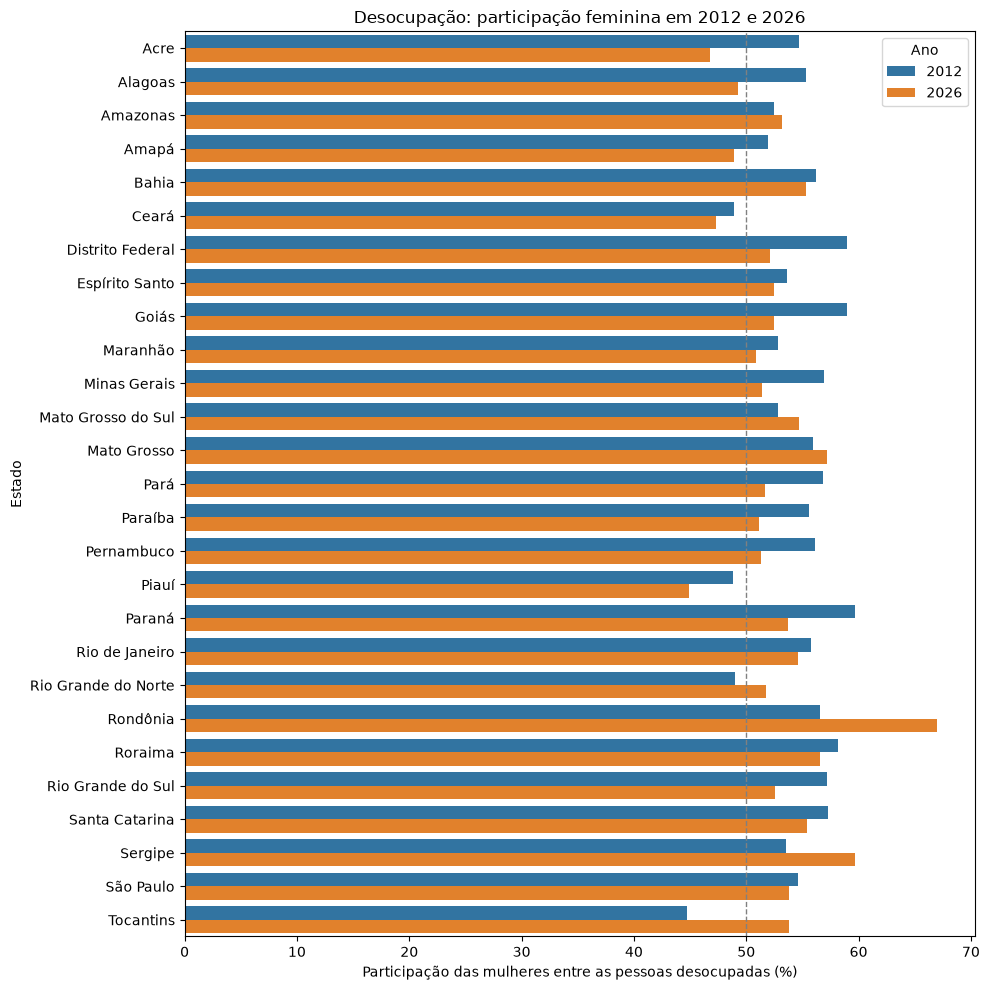

In [64]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    data=derretido,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    ax=ax
)

ax.axvline(50, color="gray", linestyle="--", linewidth=1)


ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("Estado")
ax.set_title("Desocupação: participação feminina em 2012 e 2026")
ax.legend(title="Ano")


fig.tight_layout()


plt.show()